# 04 · Análisis longitudinal y comparativo del discurso

Este notebook desarrolla el análisis sustantivo del corpus elegible para análisis textual
(`analysis_eligible == True`) construido y caracterizado en el Notebook 03.

El análisis se organiza de acuerdo con los objetivos del TFM:

1. **Patrones léxicos y discursivos:** identificar vocabulario y combinaciones léxicas
   características, así como sus cambios entre periodos.
2. **Reconocimiento y denominación de la violencia machista:** estudiar la evolución de
   las modalidades de reconocimiento y de expresiones como *femicidio*, *feminicidio*,
   *violencia de género* y *violencia machista*.
3. **Comparación entre contextos:** identificar patrones compartidos y particularidades
   entre Argentina y México, controlando descriptivamente la composición por medio.

El notebook utiliza recuentos absolutos únicamente para describir volumen. Las comparaciones
temporales y entre países se realizan principalmente mediante **porcentajes dentro de cada
grupo**, **frecuencias por 10.000 palabras** y medidas de **especificidad léxica**.

## 1. Configuración

In [1]:
from pathlib import Path
from collections import Counter
import math
import re
import sys
import warnings
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "outputs").exists():
            return candidate
    raise RuntimeError(
        "No se pudo localizar la raíz del repositorio. "
        "Ejecuta el notebook dentro de tfm-media-violence-analysis."
    )


ROOT = find_repo_root()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


START_YEAR, END_YEAR = 2015, 2025

CORPUS_PATH = (
    ROOT
    / "outputs"
    / "analysis"
    / "2015_2025"
    / "articles.parquet"
)

FIGURES_DIR = (
    ROOT
    / "outputs"
    / "reports"
    / "figures"
    / "04_analisis_longitudinal_discursivo"
)

TABLES_DIR = (
    ROOT
    / "outputs"
    / "reports"
    / "tables"
    / "04_analisis_longitudinal_discursivo"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Corpus:", CORPUS_PATH.relative_to(ROOT))

ROOT: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis
Corpus: outputs\analysis\2015_2025\articles.parquet


In [2]:
from src.visualization.palette import COLORS

TEXT_COLOR = COLORS["text"]
GRID_COLOR = COLORS["grid"]

COUNTRY_COLORS = {
    "Argentina": COLORS["argentina"],
    "México": COLORS["mexico_dark"],
}

SOURCE_LABELS = {
    "clarin_arg": "Clarín",
    "lanacion": "La Nación",
    "pagina12": "Página/12",
    "eluniversal_mx": "El Universal",
    "milenio": "Milenio",
    "jornada": "La Jornada",
}

SOURCE_ORDER = {
    "Argentina": ["Clarín", "La Nación", "Página/12"],
    "México": ["El Universal", "Milenio", "La Jornada"],
}

RECOGNITION_LABELS = {
    "explicit_femicide_feminicide": "Femicidio/feminicidio explícito",
    "contextual_without_explicit_label": "Reconocimiento contextual",
    "explicit_gender_violence": "Marco de género",
}

RECOGNITION_ORDER = [
    "Femicidio/feminicidio explícito",
    "Reconocimiento contextual",
    "Marco de género",
]

RECOGNITION_COLORS = {
    "Femicidio/feminicidio explícito": COLORS["violet_main"],
    "Reconocimiento contextual": COLORS["violet_400"],
    "Marco de género": COLORS["violet_200"],
}

PERIOD_ORDER = ["2015-2018", "2019-2021", "2022-2025"]

In [3]:
def fmt_int(value):
    return f"{int(round(value)):,}".replace(",", ".")


def fmt_pct(value, decimals=1):
    return f"{value:.{decimals}f}%".replace(".", ",")


def assert_columns(df, columns, name="DataFrame"):
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"Faltan columnas en {name}: {missing}")


def save_figure(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Figura:", path.relative_to(ROOT))


def save_table(df, name, index=False):
    path = TABLES_DIR / name
    df.to_csv(path, index=index, encoding="utf-8-sig")
    print("Tabla:", path.relative_to(ROOT))


def add_source_labels(df):
    out = df.copy()
    out["newspaper"] = out["source"].map(SOURCE_LABELS).fillna(out["source"])
    out["country"] = (
        out["country"]
        .astype("string")
        .replace({"MΘxico": "México", "Mexico": "México"})
    )
    return out


def clean_axes(ax, axis="y"):
    ax.grid(axis=axis, color=GRID_COLOR, linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def cramers_v(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    denom = min(r - 1, k - 1)
    v = math.sqrt((chi2 / n) / denom) if n > 0 and denom > 0 else np.nan
    return chi2, p, dof, v, expected

## 2. Carga y controles del corpus textual

A diferencia de las secciones descriptivas del Notebook 03, a partir de aquí se utiliza
exclusivamente el subconjunto elegible para análisis textual. Esto evita que documentos
sin texto suficiente alteren denominadores, frecuencias léxicas o comparaciones.

In [ ]:
if not CORPUS_PATH.exists():
    raise FileNotFoundError(f"No existe {CORPUS_PATH}")

articles_all = pd.read_parquet(CORPUS_PATH)
articles_all = add_source_labels(articles_all)

required = [
    "analysis_identity",
    "analysis_text",
    "analysis_text_length",
    "analysis_eligible",
    "analysis_year",
    "analysis_period",
    "country",
    "source",
    "newspaper",
    "gender_recognition_mode",
]

assert_columns(articles_all, required, "articles_all")

analysis_corpus = (
    articles_all.loc[articles_all["analysis_eligible"].eq(True)]
    .copy()
    .reset_index(drop=True)
)

analysis_corpus["analysis_year"] = (
    pd.to_numeric(analysis_corpus["analysis_year"], errors="coerce")
    .astype("Int64")
)

analysis_corpus["recognition_label"] = (
    analysis_corpus["gender_recognition_mode"]
    .map(RECOGNITION_LABELS)
)

checks = pd.DataFrame({
    "Control": [
        "Todos elegibles",
        "Identidad analítica única",
        "Texto no vacío",
        "Texto >= 200 caracteres",
        "Año disponible",
        "Año entre 2015 y 2025",
        "País disponible",
        "Modalidad de reconocimiento mapeada",
    ],
    "Resultado": [
        bool(analysis_corpus["analysis_eligible"].all()),
        bool(analysis_corpus["analysis_identity"].is_unique),
        bool(analysis_corpus["analysis_text"].fillna(
            "").str.strip().ne("").all()),
        bool(analysis_corpus["analysis_text_length"].ge(200).all()),
        bool(analysis_corpus["analysis_year"].notna().all()),
        bool(analysis_corpus["analysis_year"].between(
            START_YEAR, END_YEAR).all()),
        bool(analysis_corpus["country"].notna().all()),
        bool(analysis_corpus["recognition_label"].notna().all()),
    ],
})

display(checks)
assert checks["Resultado"].all(
), "Falló al menos un control del corpus textual."

print("Corpus analítico consolidado:", fmt_int(len(articles_all)))
print("Corpus elegible para análisis textual:", fmt_int(len(analysis_corpus)))

,Control,Resultado
0,Todos elegibles,True
1,Identidad analítica única,True
2,Texto no vacío,True
3,Texto >= 200 caracteres,True
4,Año disponible,True
5,Año entre 2015 y 2025,True
6,País disponible,True
7,Modalidad de reconocimiento mapeada,True


Corpus analítico consolidado: 3.497
Corpus elegible para análisis textual: 3.419


## 3. Diseño analítico y denominadores

Se utilizarán tres denominadores distintos según la pregunta:

- **porcentaje de artículos**: para modalidades de reconocimiento;
- **frecuencia por 10.000 palabras**: para comparar expresiones concretas entre corpus de
  diferente tamaño;
- **frecuencia documental**: para vocabulario y n-gramas, reduciendo el peso de repeticiones
  dentro de una misma noticia.

Las comparaciones país-año se interpretarán junto con la composición por medio para evitar
confundir cambios discursivos con cambios en la disponibilidad de fuentes.

In [5]:
analysis_design = pd.DataFrame({
    "Pregunta": [
        "Modalidad de reconocimiento",
        "Uso de expresiones específicas",
        "Patrones léxicos",
        "Diferencias entre países",
        "Cambio entre periodos",
        "Heterogeneidad por medio",
    ],
    "Unidad / medida": [
        "% de artículos dentro de país-año",
        "ocurrencias por 10.000 palabras",
        "frecuencia documental y n-gramas",
        "log-odds de términos",
        "log-odds temprano vs. reciente",
        "% de artículos y concentración de fuentes",
    ],
})
display(analysis_design)

,Pregunta,Unidad / medida
0,Modalidad de reconocimiento,% de artículos dentro de país-año
1,Uso de expresiones específicas,ocurrencias por 10.000 palabras
2,Patrones léxicos,frecuencia documental y n-gramas
3,Diferencias entre países,log-odds de términos
4,Cambio entre periodos,log-odds temprano vs. reciente
5,Heterogeneidad por medio,% de artículos y concentración de fuentes


## 4. Evolución de las modalidades de reconocimiento

Esta sección responde directamente al objetivo relativo a la denominación y al grado de
explicitud con que las noticias reconocen la violencia machista. Los porcentajes se calculan
**dentro de cada país y año**, por lo que cada barra anual suma 100 %.

In [6]:
recognition_year_country = (
    analysis_corpus
    .groupby(
        ["country", "analysis_year", "recognition_label"],
        observed=True,
        as_index=False,
    )
    .size()
    .rename(columns={"size": "Documentos"})
)

recognition_year_country["Total_pais_anio"] = (
    recognition_year_country
    .groupby(["country", "analysis_year"])["Documentos"]
    .transform("sum")
)

recognition_year_country["Porcentaje"] = (
    100
    * recognition_year_country["Documentos"]
    / recognition_year_country["Total_pais_anio"]
)

recognition_year_country = (
    recognition_year_country
    .sort_values(["country", "analysis_year", "recognition_label"])
)

display(recognition_year_country.head(20))
save_table(
    recognition_year_country,
    "01_modalidad_reconocimiento_pais_anio.csv",
)

,country,analysis_year,recognition_label,Documentos,Total_pais_anio,Porcentaje
0,Argentina,2015,Femicidio/feminicidio explícito,74,112,66.071
1,Argentina,2015,Marco de género,12,112,10.714
2,Argentina,2015,Reconocimiento contextual,26,112,23.214
3,Argentina,2016,Femicidio/feminicidio explícito,179,229,78.166
4,Argentina,2016,Marco de género,15,229,6.550
5,Argentina,2016,Reconocimiento contextual,35,229,15.284
6,Argentina,2017,Femicidio/feminicidio explícito,75,100,75.000
7,Argentina,2017,Marco de género,9,100,9.000
8,Argentina,2017,Reconocimiento contextual,16,100,16.000
9,Argentina,2018,Femicidio/feminicidio explícito,46,66,69.697


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\01_modalidad_reconocimiento_pais_anio.csv


In [7]:
from matplotlib.patches import Patch


def plot_recognition_comparison(data):

    years = list(
        range(
            START_YEAR,
            END_YEAR + 1,
        )
    )

    countries = [
        "Argentina",
        "México",
    ]

    # ------------------------------------------------------
    # Orden de apilamiento
    # ------------------------------------------------------

    categories = [
        "Femicidio/feminicidio explícito",
        "Reconocimiento contextual",
        "Marco de género",
    ]

    category_colors = {

        "Femicidio/feminicidio explícito":
            COLORS["violet_main"],

        "Reconocimiento contextual":
            COLORS["violet_400"],

        "Marco de género":
            COLORS["violet_200"],
    }

    # ------------------------------------------------------
    # Completar combinaciones ausentes con 0
    # ------------------------------------------------------

    full_index = pd.MultiIndex.from_product(
        [
            countries,
            years,
            categories,
        ],
        names=[
            "country",
            "analysis_year",
            "recognition_label",
        ],
    )

    plot_data = (
        data
        .set_index(
            [
                "country",
                "analysis_year",
                "recognition_label",
            ]
        )["Porcentaje"]
        .reindex(
            full_index,
            fill_value=0,
        )
        .reset_index()
    )

    # ------------------------------------------------------
    # Posiciones
    # ------------------------------------------------------

    x = np.arange(len(years))
    width = 0.32

    positions = {
        "Argentina": x - width / 2,
        "México": x + width / 2,
    }

    fig, ax = plt.subplots(
        figsize=(13, 6.2)
    )

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # ------------------------------------------------------
    # Barras
    # ------------------------------------------------------

    for country in countries:

        subset = plot_data.loc[
            plot_data["country"].eq(country)
        ]

        bottom = np.zeros(
            len(years)
        )

        for category in categories:

            values = (
                subset.loc[
                    subset["recognition_label"].eq(
                        category
                    )
                ]
                .set_index("analysis_year")
                .reindex(years)["Porcentaje"]
                .fillna(0)
                .to_numpy()
            )

            ax.bar(
                positions[country],
                values,
                width=width,
                bottom=bottom,
                color=category_colors[
                    category
                ],
                edgecolor="white",
                linewidth=0.8,
                zorder=3,
            )

            bottom += values

    # ------------------------------------------------------
    # AR / MX debajo de cada barra
    # ------------------------------------------------------

    label_y = -5.0

    for i in range(len(years)):

        ax.text(
            positions["Argentina"][i],
            label_y,
            "AR",
            ha="center",
            va="top",
            fontsize=8,
            fontweight="bold",
            color=COUNTRY_COLORS[
                "Argentina"
            ],
        )

        ax.text(
            positions["México"][i],
            label_y,
            "MX",
            ha="center",
            va="top",
            fontsize=8,
            fontweight="bold",
            color=COUNTRY_COLORS[
                "México"
            ],
        )

    # ------------------------------------------------------
    # Ejes
    # ------------------------------------------------------

    ax.set_xticks(x)

    ax.set_xticklabels(
        years
    )

    ax.set_xlabel(
        "Año",
        labelpad=22,
    )

    ax.set_ylabel(
        "Porcentaje de artículos"
    )

    ax.set_title(
        "Evolución de las modalidades de reconocimiento por país",
        fontsize=14,
        fontweight="bold",
        color=COLORS["text"],
        pad=14,
    )

    # ------------------------------------------------------
    # Estilo
    # ------------------------------------------------------

    ax.grid(
        axis="y",
        color=COLORS["grid"],
        linewidth=0.8,
        alpha=0.8,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(
        False
    )
    ax.spines["right"].set_visible(
        False
    )

    # Todas las barras representan 100 %
    ax.set_ylim(
        -8,
        105,
    )

    ax.set_yticks(
        np.arange(
            0,
            101,
            20,
        )
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda y, _:
                f"{int(y)}%"
                if y >= 0
                else ""
        )
    )

    # ------------------------------------------------------
    # Leyenda
    # ------------------------------------------------------

    handles = [
        Patch(
            facecolor=category_colors[
                category
            ],
            label=category,
        )
        for category in categories
    ]

    ax.legend(
        handles=handles,
        ncol=3,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            -0.14,
        ),
    )

    fig.subplots_adjust(
        bottom=0.22
    )

    save_figure(
        fig,
        "01_modalidad_reconocimiento_pais_anio.png",
    )

    plt.show()

Figura: outputs\reports\figures\04_analisis_longitudinal_discursivo\01_modalidad_reconocimiento_pais_anio.png


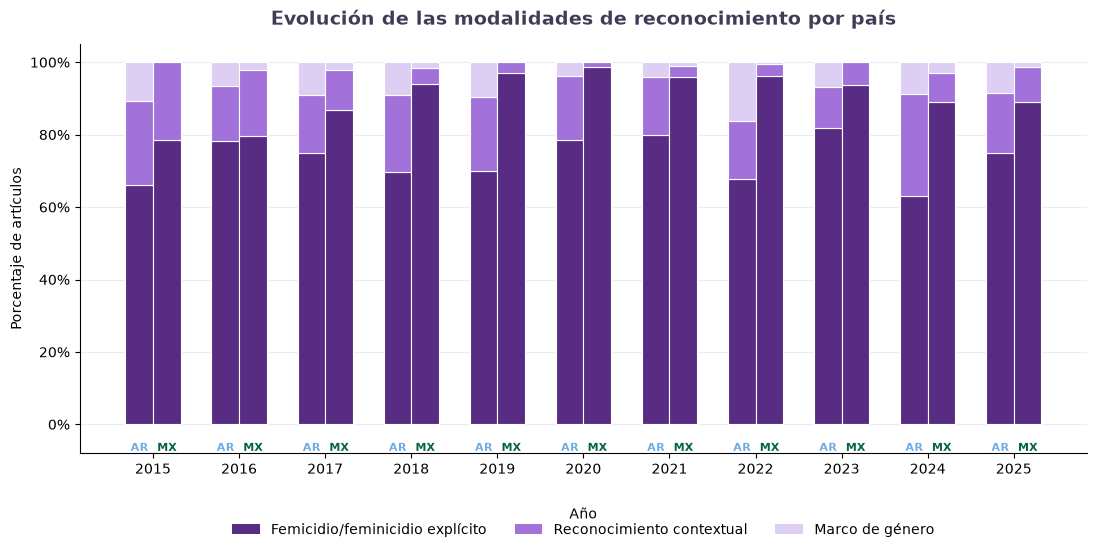

In [8]:
plot_recognition_comparison(
    recognition_year_country
)

### 4.1 Asociación entre país, periodo y modalidad

Las pruebas siguientes se utilizan como apoyo descriptivo. Un resultado significativo indica
que las distribuciones no son independientes, pero **no demuestra causalidad** ni identifica
por sí solo el origen de la diferencia. Se reporta también V de Cramér como tamaño de asociación.

In [9]:
association_results = []

# País × modalidad en el conjunto completo
table = pd.crosstab(
    analysis_corpus["country"],
    analysis_corpus["recognition_label"],
).reindex(columns=RECOGNITION_ORDER, fill_value=0)

chi2, p, dof, v, expected = cramers_v(table)

association_results.append({
    "Comparación": "País × modalidad (2015-2025)",
    "Chi2": chi2,
    "gl": dof,
    "p_value": p,
    "Cramers_V": v,
    "N": int(table.to_numpy().sum()),
})

# Periodo × modalidad dentro de cada país
for country in ["Argentina", "México"]:
    subset = analysis_corpus.loc[analysis_corpus["country"].eq(country)]

    table = pd.crosstab(
        subset["analysis_period"],
        subset["recognition_label"],
    ).reindex(index=PERIOD_ORDER, columns=RECOGNITION_ORDER, fill_value=0)

    # Eliminar filas totalmente vacías si las hubiera.
    table = table.loc[table.sum(axis=1).gt(0)]

    chi2, p, dof, v, expected = cramers_v(table)

    association_results.append({
        "Comparación": f"Periodo × modalidad — {country}",
        "Chi2": chi2,
        "gl": dof,
        "p_value": p,
        "Cramers_V": v,
        "N": int(table.to_numpy().sum()),
    })

association_results = pd.DataFrame(association_results)

display(association_results)
save_table(
    association_results,
    "02_asociaciones_modalidad_reconocimiento.csv",
)

,Comparación,Chi2,gl,p_value,Cramers_V,N
0,País × modalidad (2015-2025),248.042,2,0.000,0.269,3419
1,Periodo × modalidad — Argentina,1.284,4,0.864,0.023,1200
2,Periodo × modalidad — México,35.579,4,0.000,0.090,2219


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\02_asociaciones_modalidad_reconocimiento.csv


## 5. Evolución de expresiones de denominación

Además de la categoría asignada por el pipeline, se mide directamente la presencia de
expresiones relevantes en el texto. Las frecuencias se normalizan por 10.000 palabras para
hacer comparables años y países con volúmenes documentales diferentes.

Estas expresiones no se interpretan como sinónimos perfectos: se muestran por separado porque
su elección forma parte del fenómeno estudiado.

In [ ]:
DENOMINATION_PATTERNS = {
    "femicidio": r"\bfemicid(?:io|ios|a|as)\b",
    "feminicidio": r"\bfeminicid(?:io|ios|a|as)\b",
    "violencia de género": r"\bviolencia\s+de\s+g[eé]nero\b",
    "violencia machista": r"\bviolencia\s+machista\b",
}


def count_pattern(text, pattern):
    if not isinstance(text, str):
        return 0
    return len(re.findall(pattern, text.lower(), flags=re.IGNORECASE))


denomination = analysis_corpus[
    ["analysis_identity", "country", "analysis_year", "analysis_text", "word_count"]
].copy()

denomination["word_count"] = pd.to_numeric(
    denomination["word_count"],
    errors="coerce",
).fillna(0)

for label, pattern in DENOMINATION_PATTERNS.items():
    denomination[label] = denomination["analysis_text"].map(
        lambda text: count_pattern(text, pattern)
    )

denomination_year = (
    denomination
    .groupby(["country", "analysis_year"], as_index=False)
    .agg(
        Palabras=("word_count", "sum"),
        Documentos=("analysis_identity", "nunique"),
        **{
            label: (label, "sum")
            for label in DENOMINATION_PATTERNS
        },
    )
)

for label in DENOMINATION_PATTERNS:
    denomination_year[f"{label}_por_10k"] = (
        10000
        * denomination_year[label]
        / denomination_year["Palabras"].replace(0, np.nan)
    )

display(denomination_year.head())
save_table(
    denomination_year,
    "03_denominaciones_pais_anio.csv",
)

,country,analysis_year,Palabras,Documentos,femicidio,feminicidio,violencia de género,violencia machista,femicidio_por_10k,feminicidio_por_10k,violencia de género_por_10k,violencia machista_por_10k
0,Argentina,2015,64899,112,179,4,100,26,27.581,0.616,15.409,4.006
1,Argentina,2016,168873,229,525,8,247,110,31.088,0.474,14.626,6.514
2,Argentina,2017,60585,100,186,0,66,13,30.701,0.000,10.894,2.146
3,Argentina,2018,43718,66,101,0,29,3,23.103,0.000,6.633,0.686
4,Argentina,2019,42008,63,146,1,34,6,34.755,0.238,8.094,1.428


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\03_denominaciones_pais_anio.csv


Figura: outputs\reports\figures\04_analisis_longitudinal_discursivo\02_evolucion_denominaciones.png


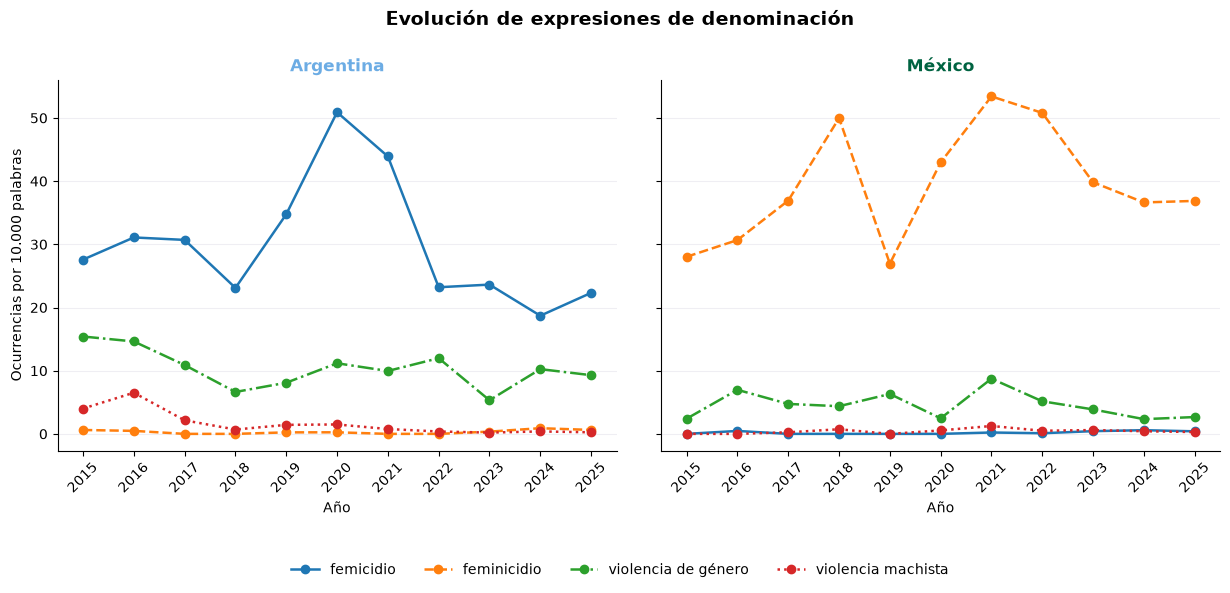

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.8),
    sharey=True,
)

line_styles = ["-", "--", "-.", ":"]

for ax, country in zip(axes, ["Argentina", "México"]):
    subset = (
        denomination_year
        .loc[denomination_year["country"].eq(country)]
        .sort_values("analysis_year")
    )

    for (label, _), linestyle in zip(
        DENOMINATION_PATTERNS.items(),
        line_styles,
    ):
        ax.plot(
            subset["analysis_year"],
            subset[f"{label}_por_10k"],
            marker="o",
            linewidth=1.8,
            linestyle=linestyle,
            label=label,
        )

    ax.set_title(
        country,
        fontweight="bold",
        color=COUNTRY_COLORS[country],
    )
    ax.set_xlabel("Año")
    ax.set_xticks(range(START_YEAR, END_YEAR + 1))
    ax.tick_params(axis="x", rotation=45)
    clean_axes(ax)

axes[0].set_ylabel("Ocurrencias por 10.000 palabras")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Evolución de expresiones de denominación",
    fontsize=14,
    fontweight="bold",
)

fig.subplots_adjust(bottom=0.22, top=0.86, wspace=0.08)
save_figure(fig, "02_evolucion_denominaciones.png")
plt.show()

## 6. Preparación léxica

Para el análisis léxico se aplica una normalización ligera: minúsculas, eliminación de URLs,
tokenización alfabética y exclusión de palabras funcionales frecuentes. No se realiza stemming
ni lematización, para conservar formas lingüísticas observables y evitar introducir una
dependencia adicional del modelo lingüístico.

La lista de exclusión se utiliza únicamente para análisis de vocabulario; el texto original
permanece intacto.

In [ ]:
STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como", "con", "contra", "cual",
    "cuando", "de", "del", "desde", "donde", "dos", "el", "ella", "ellas", "ellos", "en", "entre",
    "era", "es", "esa", "esas", "ese", "eso", "esos", "esta", "estaba", "están", "estar", "este",
    "esto", "estos", "fue", "ha", "han", "hasta", "hay", "la", "las", "le", "les", "lo", "los", "más",
    "me", "mi", "mis", "muy", "no", "nos", "o", "para", "pero", "por", "porque", "que", "qué", "se",
    "ser", "si", "sí", "sin", "sobre", "su", "sus", "también", "te", "tiene", "tienen", "todo",
    "todos", "tras", "tu", "un", "una", "uno", "unos", "y", "ya", "yo",
    "e", "u", "ni", "muy", "cada", "durante", "según", "sido", "son", "era", "eran", "fueron",
    "había", "habían", "hacia", "ese", "esa", "esas", "esos", "aquel", "aquella", "aquellos",
    "aquellas", "mismo", "misma", "mismos", "mismas"
}

TOKEN_RE = re.compile(r"[a-záéíóúüñ]{3,}", flags=re.IGNORECASE)


def tokenize(text):
    if not isinstance(text, str):
        return []

    text = re.sub(r"https?://\S+|www\.\S+", " ", text.lower())
    tokens = TOKEN_RE.findall(text)

    return [
        token
        for token in tokens
        if token not in STOPWORDS_ES
    ]


analysis_corpus["tokens"] = analysis_corpus["analysis_text"].map(tokenize)
analysis_corpus["token_count_nlp"] = analysis_corpus["tokens"].map(len)

token_audit = (
    analysis_corpus
    .groupby("country", as_index=False)
    .agg(
        Documentos=("analysis_identity", "nunique"),
        Tokens=("token_count_nlp", "sum"),
        Mediana_tokens=("token_count_nlp", "median"),
    )
)

display(token_audit)
save_table(token_audit, "04_auditoria_tokens.csv")

,country,Documentos,Tokens,Mediana_tokens
0,Argentina,1200,463184,328.000
1,México,2219,545073,206.000


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\04_auditoria_tokens.csv


## 7. Análisis léxico

Se calcula la **frecuencia documental**: cuántos artículos contienen cada término al menos una vez. Esta medida es preferible al recuento bruto para identificar vocabulario extendido en el
corpus sin sobrerrepresentar noticias que repiten muchas veces una palabra.

### 7.1 Unigramas más frecuentes por país

In [13]:
def build_annual_unigram_frequencies(data, top_n=15):

    rows = []

    for (country, year), group in data.groupby(
        ["country", "analysis_year"]
    ):

        counter = Counter()
        total_tokens = 0

        for text in group["analysis_text"].dropna():

            tokens = [
                token
                for token in tokenize(text)
                if token not in STOPWORDS_ES
            ]

            counter.update(tokens)
            total_tokens += len(tokens)

        for term, count in counter.most_common(top_n):

            rows.append({
                "country": country,
                "analysis_year": int(year),
                "term": term,
                "count": count,
                "total_tokens": total_tokens,
                "frequency_10k": (
                    10_000 * count / total_tokens
                    if total_tokens
                    else 0
                ),
            })

    return pd.DataFrame(rows)

In [14]:
annual_unigrams = build_annual_unigram_frequencies(
    analysis_corpus,
    top_n=15,
)

display(annual_unigrams.head(30))

,country,analysis_year,term,count,total_tokens,frequency_10k
0,Argentina,2015,mujeres,260,32304,80.485
1,Argentina,2015,violencia,260,32304,80.485
2,Argentina,2015,mujer,196,32304,60.674
3,Argentina,2015,años,191,32304,59.126
4,Argentina,2015,género,167,32304,51.696
5,Argentina,2015,casa,124,32304,38.385
6,Argentina,2015,víctima,111,32304,34.361
7,Argentina,2015,femicidio,108,32304,33.432
8,Argentina,2015,dijo,107,32304,33.123
9,Argentina,2015,justicia,107,32304,33.123


In [15]:
for country in ["Argentina", "México"]:

    print("\n" + "=" * 70)
    print(country.upper())
    print("=" * 70)

    table = (
        annual_unigrams[
            annual_unigrams["country"].eq(country)
        ]
        .pivot(
            index="term",
            columns="analysis_year",
            values="frequency_10k",
        )
        .fillna(0)
        .round(2)
    )

    display(table)


ARGENTINA


analysis_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
term,,,,,,,,,,,
abuso,0.000,0.000,0.000,27.690,0.000,0.000,0.000,0.000,0.000,0.000,0.000
asesinada,0.000,0.000,0.000,0.000,29.530,0.000,0.000,0.000,0.000,0.000,0.000
año,0.000,27.460,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
años,59.130,65.980,99.420,82.610,80.960,70.010,88.160,42.260,54.680,66.640,64.240
capitanich,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,33.730,0.000,0.000
casa,38.390,32.810,48.570,52.200,58.100,88.020,40.770,36.980,40.480,33.440,33.290
caso,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,37.060,26.100,29.230
cecilia,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,71.600,0.000,0.000
chaco,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,31.920,0.000,0.000



MÉXICO


analysis_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
term,,,,,,,,,,,
amlo,0.000,0.000,0.000,0.000,41.850,0.000,0.000,0.000,0.000,0.000,0.000
año,0.000,0.000,0.000,0.000,33.000,0.000,0.000,0.000,0.000,0.000,0.000
años,33.500,41.780,51.070,55.920,0.000,26.580,55.470,51.860,49.480,52.550,69.370
caso,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,30.460,26.440,33.950
casos,0.000,0.000,0.000,41.580,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ciento,0.000,0.000,0.000,0.000,0.000,0.000,35.800,0.000,0.000,0.000,0.000
ciudad,0.000,0.000,0.000,0.000,0.000,0.000,35.800,35.840,36.020,32.480,0.000
dijo,47.530,57.560,50.590,32.260,0.000,0.000,0.000,0.000,0.000,0.000,0.000
diputados,0.000,0.000,0.000,0.000,45.070,0.000,0.000,0.000,0.000,0.000,0.000


In [16]:
annual_unigrams["rank"] = (
    annual_unigrams
    .groupby(["country", "analysis_year"])
    ["frequency_10k"]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

In [17]:
annual_unigrams[
    annual_unigrams["country"].eq("Argentina")
].sort_values(
    ["analysis_year", "rank"]
).head(50)

,country,analysis_year,term,count,total_tokens,frequency_10k,rank
0,Argentina,2015,mujeres,260,32304,80.485,1
1,Argentina,2015,violencia,260,32304,80.485,2
2,Argentina,2015,mujer,196,32304,60.674,3
3,Argentina,2015,años,191,32304,59.126,4
4,Argentina,2015,género,167,32304,51.696,5
5,Argentina,2015,casa,124,32304,38.385,6
6,Argentina,2015,víctima,111,32304,34.361,7
7,Argentina,2015,femicidio,108,32304,33.432,8
8,Argentina,2015,dijo,107,32304,33.123,9
9,Argentina,2015,justicia,107,32304,33.123,10


In [18]:
# ============================================================
# Unigramas más frecuentes por país
# ============================================================

unigrams_country = (
    annual_unigrams
    .groupby(
        ["country", "term"],
        as_index=False
    )
    .agg(
        count=("count", "sum"),
        total_tokens=("total_tokens", "sum"),
    )
)

unigrams_country["frequency_10k"] = (
    10_000
    * unigrams_country["count"]
    / unigrams_country["total_tokens"]
)

In [19]:
def build_country_unigram_frequencies(data, top_n=15):

    rows = []

    for country, group in data.groupby("country"):

        counter = Counter()
        total_tokens = 0

        for text in group["analysis_text"].dropna():

            tokens = [
                token
                for token in tokenize(text)
                if token not in STOPWORDS_ES
            ]

            counter.update(tokens)
            total_tokens += len(tokens)

        for term, count in counter.most_common(top_n):

            rows.append({
                "country": country,
                "term": term,
                "count": count,
                "total_tokens": total_tokens,
                "frequency_10k": (
                    10_000 * count / total_tokens
                    if total_tokens
                    else 0
                ),
            })

    return pd.DataFrame(rows)


country_unigrams = build_country_unigram_frequencies(
    analysis_corpus,
    top_n=15,
)

display(country_unigrams)

,country,term,count,total_tokens,frequency_10k
0,Argentina,años,3101,463184,66.950
1,Argentina,violencia,2168,463184,46.806
2,Argentina,mujer,2154,463184,46.504
3,Argentina,mujeres,1898,463184,40.977
4,Argentina,casa,1896,463184,40.934
5,Argentina,femicidio,1635,463184,35.299
6,Argentina,víctima,1505,463184,32.492
7,Argentina,dijo,1453,463184,31.370
8,Argentina,género,1430,463184,30.873
9,Argentina,está,1400,463184,30.226


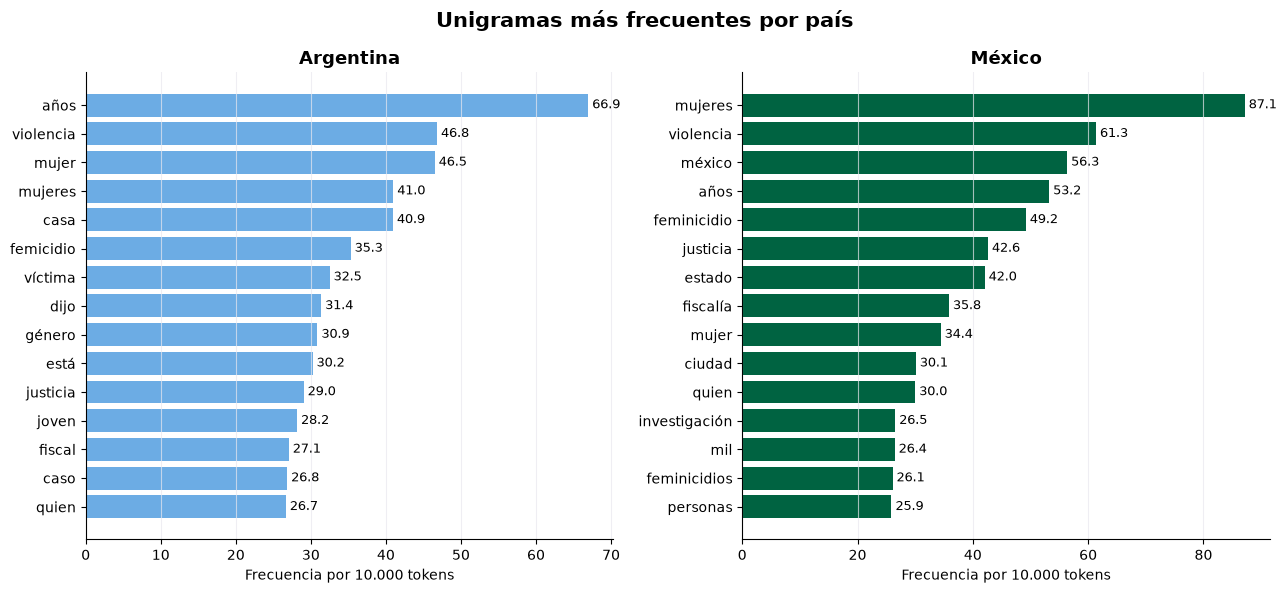

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 6),
)

country_colors = {
    "Argentina": COLORS["argentina"],
    "México": COLORS["mexico_dark"],
}

for ax, country in zip(
    axes,
    ["Argentina", "México"]
):

    subset = (
        country_unigrams[
            country_unigrams["country"].eq(country)
        ]
        .sort_values("frequency_10k")
    )

    bars = ax.barh(
        subset["term"],
        subset["frequency_10k"],
        color=country_colors[country],
    )

    # Valor al final de cada barra
    for bar, value in zip(
        bars,
        subset["frequency_10k"]
    ):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {value:.1f}",
            va="center",
            fontsize=9,
        )

    ax.set_title(
        country,
        fontsize=13,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Frecuencia por 10.000 tokens"
    )

    ax.grid(
        axis="x",
        color=COLORS["grid"],
        linewidth=0.8,
        alpha=0.7,
    )

    ax.grid(
        axis="y",
        visible=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig.suptitle(
    "Unigramas más frecuentes por país",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

plt.show()

### 7.2 Evolución anual de unigramas seleccionados

In [21]:
def build_annual_term_frequencies(data, terms):
    rows = []

    for (country, year), group in data.groupby(
        ["country", "analysis_year"]
    ):
        tokens = []

        for text in group["analysis_text"].dropna():
            tokens.extend(tokenize(text))

        counts = Counter(tokens)
        total_tokens = len(tokens)

        for term in terms:
            count = counts.get(term, 0)

            frequency = (
                count / total_tokens * 10_000
                if total_tokens > 0
                else np.nan
            )

            rows.append({
                "country": country,
                "analysis_year": int(year),
                "term": term,
                "count": count,
                "total_tokens": total_tokens,
                "frequency_10k": frequency,
            })

    return pd.DataFrame(rows)

In [22]:
all_tokens = []

for text in analysis_corpus["analysis_text"].dropna():
    all_tokens.extend(tokenize(text))

global_counts = Counter(all_tokens)

global_counts.most_common(30)

[('mujeres', 6648),
 ('años', 6002),
 ('violencia', 5512),
 ('mujer', 4030),
 ('justicia', 3668),
 ('méxico', 3171),
 ('estado', 2934),
 ('quien', 2870),
 ('género', 2763),
 ('dijo', 2716),
 ('feminicidio', 2704),
 ('caso', 2648),
 ('está', 2573),
 ('víctima', 2561),
 ('casa', 2523),
 ('fiscalía', 2418),
 ('ciudad', 2361),
 ('joven', 2336),
 ('vida', 2163),
 ('después', 2135),
 ('investigación', 2109),
 ('personas', 2051),
 ('víctimas', 1976),
 ('nacional', 1940),
 ('año', 1921),
 ('día', 1910),
 ('luego', 1883),
 ('seguridad', 1864),
 ('cuerpo', 1853),
 ('fiscal', 1811)]

In [23]:
term_document_frequency = Counter()

for text in analysis_corpus["analysis_text"].dropna():

    tokens = {
        token
        for token in tokenize(text)
        if token not in STOPWORDS_ES
    }

    term_document_frequency.update(tokens)

top_terms = pd.DataFrame(
    term_document_frequency.most_common(30),
    columns=["term", "document_frequency"],
)

top_terms["document_percentage"] = (
    100
    * top_terms["document_frequency"]
    / len(analysis_corpus)
)

display(top_terms)

,term,document_frequency,document_percentage
0,años,2205,64.493
1,violencia,1805,52.793
2,justicia,1698,49.664
3,mujer,1653,48.347
4,mujeres,1637,47.879
5,quien,1613,47.178
6,estado,1505,44.019
7,feminicidio,1418,41.474
8,caso,1410,41.240
9,dijo,1338,39.134


In [24]:
HEATMAP_TERMS = [
    "mujeres",
    "mujer",
    "violencia",
    "género",
    "femicidio",
    "feminicidio",
    "víctima",
    "justicia",
    "fiscalía",
    "policía",
    "pareja",
    "familia",
]

In [25]:
annual_term_freq = build_annual_term_frequencies(
    analysis_corpus,
    HEATMAP_TERMS,
)

display(annual_term_freq.head(20))

,country,analysis_year,term,count,total_tokens,frequency_10k
0,Argentina,2015,mujeres,260,32304,80.485
1,Argentina,2015,mujer,196,32304,60.674
2,Argentina,2015,violencia,260,32304,80.485
3,Argentina,2015,género,167,32304,51.696
4,Argentina,2015,femicidio,108,32304,33.432
5,Argentina,2015,feminicidio,4,32304,1.238
6,Argentina,2015,víctima,111,32304,34.361
7,Argentina,2015,justicia,107,32304,33.123
8,Argentina,2015,fiscalía,23,32304,7.120
9,Argentina,2015,policía,51,32304,15.788


In [26]:
coverage = (
    annual_term_freq
    .groupby(["country", "analysis_year"])["total_tokens"]
    .first()
    .reset_index()
)

display(coverage)

,country,analysis_year,total_tokens
0,Argentina,2015,32304
1,Argentina,2016,84116
2,Argentina,2017,30678
3,Argentina,2018,22030
4,Argentina,2019,20997
5,Argentina,2020,19996
6,Argentina,2021,19623
7,Argentina,2022,13251
8,Argentina,2023,99306
9,Argentina,2024,39468


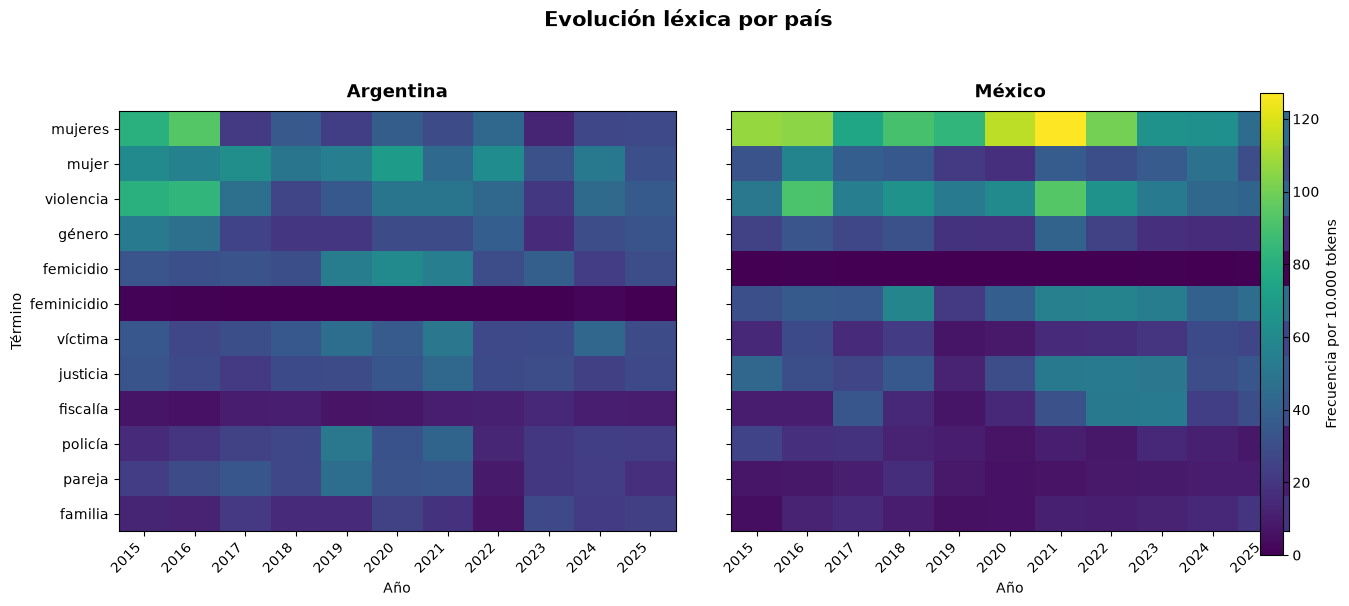

In [27]:
countries = ["Argentina", "México"]
years = list(range(2015, 2026))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    sharey=True,
)

# ------------------------------------------------------------
# Construir matrices primero para obtener una escala común
# ------------------------------------------------------------

matrices = {}

for country in countries:

    subset = annual_term_freq[
        annual_term_freq["country"].eq(country)
    ]

    matrix = (
        subset
        .pivot(
            index="term",
            columns="analysis_year",
            values="frequency_10k",
        )
        .reindex(
            index=HEATMAP_TERMS,
            columns=years,
        )
    )

    matrices[country] = matrix


# Escala común para que los colores sean comparables
vmin = 0

vmax = max(
    np.nanmax(matrix.to_numpy())
    for matrix in matrices.values()
)


# ------------------------------------------------------------
# Dibujar
# ------------------------------------------------------------

images = []

for ax, country in zip(axes, countries):

    matrix = matrices[country]

    image = ax.imshow(
        matrix.to_numpy(),
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )

    images.append(image)

    ax.set_title(
        country,
        fontsize=13,
        fontweight="bold",
        pad=10,
    )

    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(
        years,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(range(len(HEATMAP_TERMS)))
    ax.set_yticklabels(HEATMAP_TERMS)

    ax.set_xlabel("Año")


axes[0].set_ylabel("Término")


# ------------------------------------------------------------
# Barra de color común
# ------------------------------------------------------------

cbar = fig.colorbar(
    images[0],
    ax=axes,
    fraction=0.025,
    pad=0.03,
)

cbar.set_label(
    "Frecuencia por 10.000 tokens",
    rotation=90,
)


fig.suptitle(
    "Evolución léxica por país",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

fig.subplots_adjust(
    left=0.12,
    right=0.90,
    bottom=0.15,
    top=0.85,
    wspace=0.10,
)

plt.show()

### 7.3 Bigramas más frecuentes por país

El análisis de términos individuales se complementa con el estudio de secuencias de dos palabras. Esto permite identificar expresiones recurrentes y asociaciones léxicas que no son visibles mediante el análisis de frecuencias de palabras aisladas.

Las frecuencias se calculan separadamente para Argentina y México y se normalizan por 10.000 n-gramas, con el fin de facilitar la comparación entre corpus de distinto tamaño.

In [28]:
def get_ngrams(tokens, n):
    return [
        tuple(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    ]


def build_ngram_frequencies(data, n, top_n=20):

    rows = []

    for country, group in data.groupby("country"):

        counter = Counter()
        total_ngrams = 0

        for text in group["analysis_text"].dropna():

            tokens = [
                token
                for token in tokenize(text)
                if token not in STOPWORDS_ES
            ]

            ngrams = get_ngrams(tokens, n)

            counter.update(ngrams)
            total_ngrams += len(ngrams)

        for ngram, count in counter.most_common(top_n):

            rows.append({
                "country": country,
                "ngram": " ".join(ngram),
                "count": count,
                "frequency_10k": (
                    10_000 * count / total_ngrams
                    if total_ngrams
                    else 0
                ),
            })

    return pd.DataFrame(rows)

In [29]:
bigrams = build_ngram_frequencies(
    analysis_corpus,
    n=2,
    top_n=20,
)

display(bigrams)

,country,ngram,count,frequency_10k
0,Argentina,violencia género,915,19.806
1,Argentina,abuso sexual,430,9.308
2,Argentina,buenos aires,411,8.896
3,Argentina,emerenciano sena,287,6.212
4,Argentina,cecilia strzyzowski,253,5.476
5,Argentina,redes sociales,245,5.303
6,Argentina,césar sena,230,4.979
7,Argentina,marcela acuña,217,4.697
8,Argentina,tenía años,216,4.675
9,Argentina,año pasado,196,4.243


In [30]:
def plot_ngrams_by_country(data, title, top_n=15):

    countries = ["Argentina", "México"]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 7),
    )

    country_colors = {
        "Argentina": COLORS["argentina"],
        "México": COLORS["mexico_dark"],
    }

    for ax, country in zip(axes, countries):

        subset = (
            data[data["country"].eq(country)]
            .nlargest(top_n, "frequency_10k")
            .sort_values("frequency_10k")
        )

        bars = ax.barh(
            subset["ngram"],
            subset["frequency_10k"],
            color=country_colors[country],
        )

        ax.set_title(
            country,
            fontsize=13,
            fontweight="bold",
        )

        ax.set_xlabel("Frecuencia por 10.000 n-gramas")

        ax.grid(
            axis="x",
            color=COLORS["grid"],
            linewidth=0.8,
            alpha=0.7,
        )

        ax.grid(axis="y", visible=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        title,
        fontsize=15,
        fontweight="bold",
    )

    fig.tight_layout()

    plt.show()

### 7.4 Evolución anual de bigramas seleccionados

In [31]:
# ============================================================
# 7.4 Evolución anual de bigramas seleccionados
# ============================================================

def build_annual_ngram_frequencies(data, n, selected_ngrams):

    rows = []

    selected = {
        tuple(term.split())
        for term in selected_ngrams
    }

    for (country, year), group in data.groupby(
        ["country", "analysis_year"]
    ):

        counter = Counter()
        total_ngrams = 0

        for text in group["analysis_text"].dropna():

            # IMPORTANTE:
            # no eliminamos stopwords antes de construir n-gramas
            tokens = tokenize(text)

            ngrams = get_ngrams(tokens, n)

            counter.update(ngrams)
            total_ngrams += len(ngrams)

        for ngram in selected:

            count = counter.get(ngram, 0)

            rows.append({
                "country": country,
                "analysis_year": int(year),
                "ngram": " ".join(ngram),
                "count": count,
                "total_ngrams": total_ngrams,
                "frequency_10k": (
                    10_000 * count / total_ngrams
                    if total_ngrams > 0
                    else 0
                ),
            })

    return pd.DataFrame(rows)

In [32]:
SELECTED_BIGRAMS = [
    "violencia género",
    "violencia machista"
    "abuso sexual",
    "por femicidio",
    "fue asesinada",
    "derechos humanos",
    "violencia mujeres",
    "los feminicidios",
    "mujeres niñas"
]

In [33]:
annual_bigrams = build_annual_ngram_frequencies(
    analysis_corpus,
    n=2,
    selected_ngrams=SELECTED_BIGRAMS,
)

In [ ]:
def plot_annual_ngram_heatmaps(
    data,
    selected_ngrams,
    title,
):

    countries = ["Argentina", "México"]
    years = list(range(2015, 2026))

    matrices = {}

    for country in countries:

        subset = data[
            data["country"].eq(country)
        ]

        matrix = (
            subset
            .pivot(
                index="ngram",
                columns="analysis_year",
                values="frequency_10k",
            )
            .reindex(
                index=selected_ngrams,
                columns=years,
            )
            .fillna(0)
        )

        matrices[country] = matrix

    # --------------------------------------------------------
    # Escala común entre ambos países
    # --------------------------------------------------------

    vmax = max(
        np.nanmax(matrix.to_numpy())
        for matrix in matrices.values()
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6),
        sharey=True,
    )

    images = []

    for ax, country in zip(
        axes,
        countries,
    ):

        matrix = matrices[country]

        image = ax.imshow(
            matrix.to_numpy(),
            aspect="auto",
            interpolation="nearest",
            vmin=0,
            vmax=vmax,
        )

        images.append(image)

        ax.set_title(
            country,
            fontsize=13,
            fontweight="bold",
        )

        ax.set_xticks(
            range(len(years))
        )

        ax.set_xticklabels(
            years,
            rotation=45,
            ha="right",
        )

        ax.set_yticks(
            range(len(selected_ngrams))
        )

        ax.set_yticklabels(
            selected_ngrams
        )

        ax.set_xlabel("Año")

    axes[0].set_ylabel("Expresión")

    cbar = fig.colorbar(
        images[0],
        ax=axes,
        fraction=0.025,
        pad=0.03,
    )

    cbar.set_label(
        "Frecuencia por 10.000 n-gramas"
    )

    fig.suptitle(
        title,
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )

    fig.subplots_adjust(
        left=0.16,
        right=0.90,
        bottom=0.15,
        top=0.85,
        wspace=0.10,
    )

    plt.show()

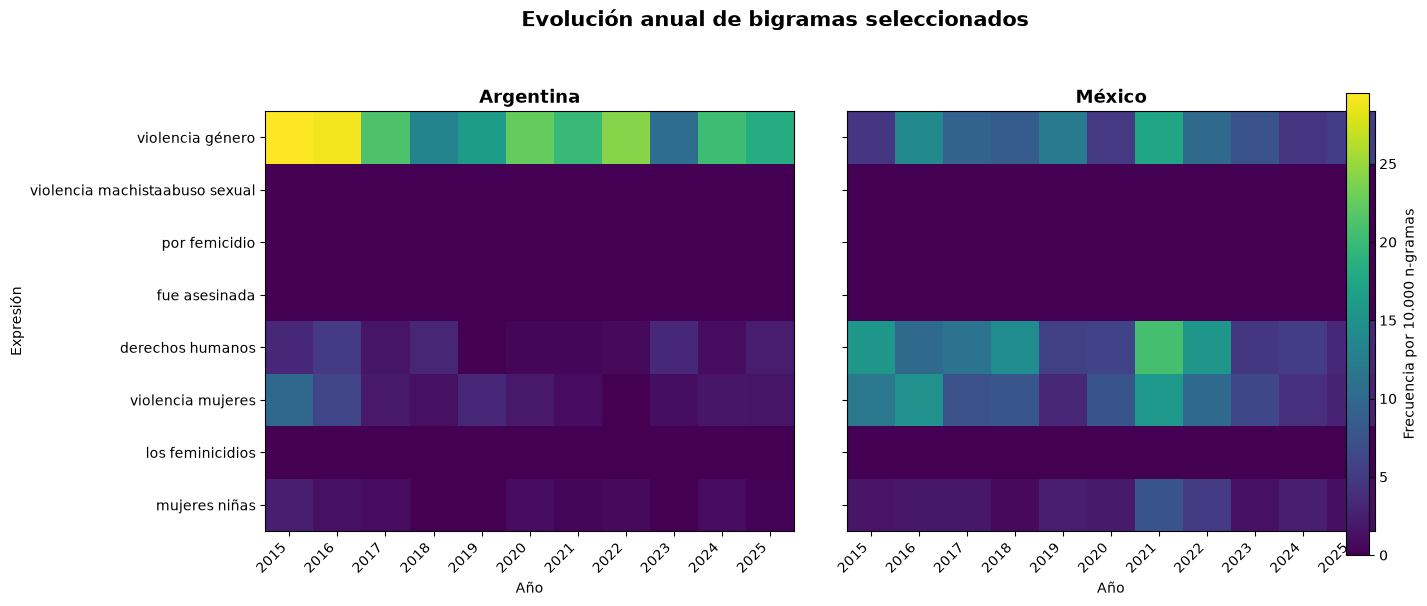

In [35]:
plot_annual_ngram_heatmaps(
    annual_bigrams,
    SELECTED_BIGRAMS,
    "Evolución anual de bigramas seleccionados",
)

### 7.5 Trigramas más frecuentes por país

In [36]:
trigrams = build_ngram_frequencies(
    analysis_corpus,
    n=3,
    top_n=20,
)


display(trigrams)

,country,ngram,count,frequency_10k
0,Argentina,provincia buenos aires,110,2.387
1,Argentina,sena marcela acuña,101,2.192
2,Argentina,emerenciano sena marcela,84,1.823
3,Argentina,ciudad buenos aires,72,1.563
4,Argentina,contexto violencia género,70,1.519
5,Argentina,abuso sexual acceso,63,1.367
6,Argentina,sexual acceso carnal,63,1.367
7,Argentina,unidad funcional instrucción,63,1.367
8,Argentina,femicidio cecilia strzyzowski,61,1.324
9,Argentina,tribunal oral criminal,58,1.259


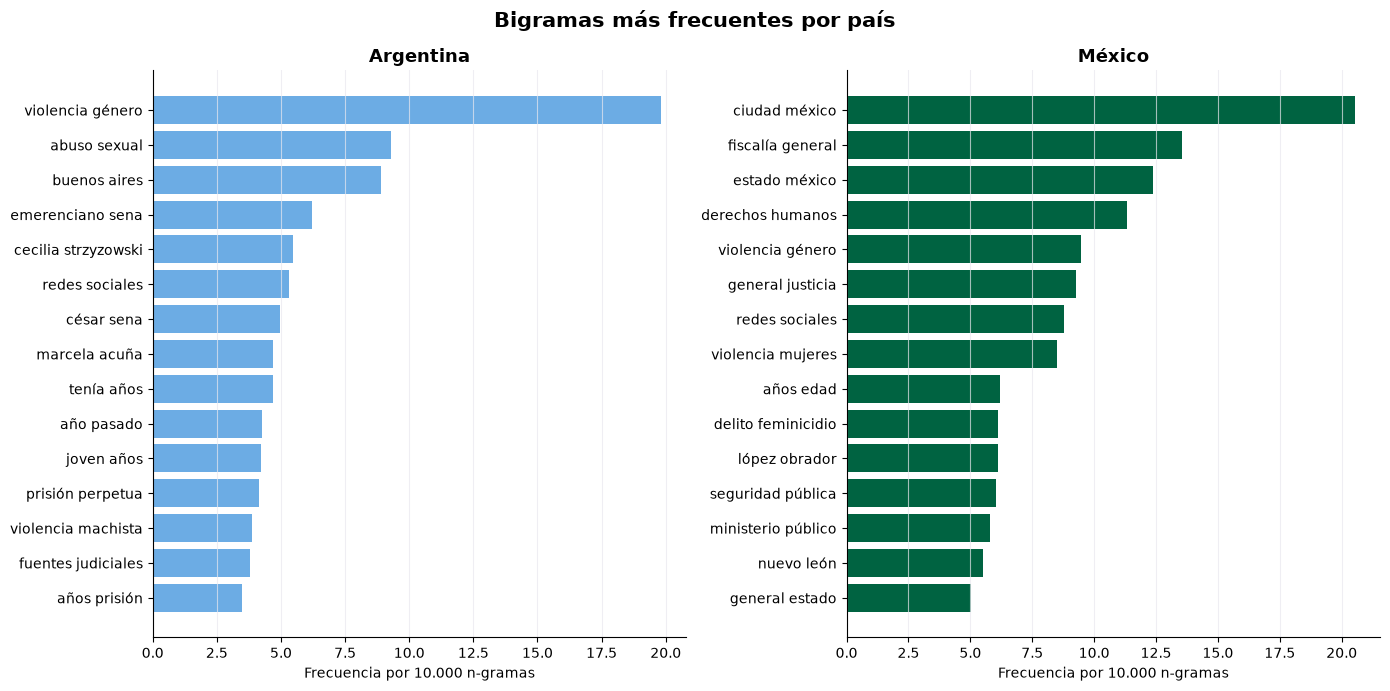

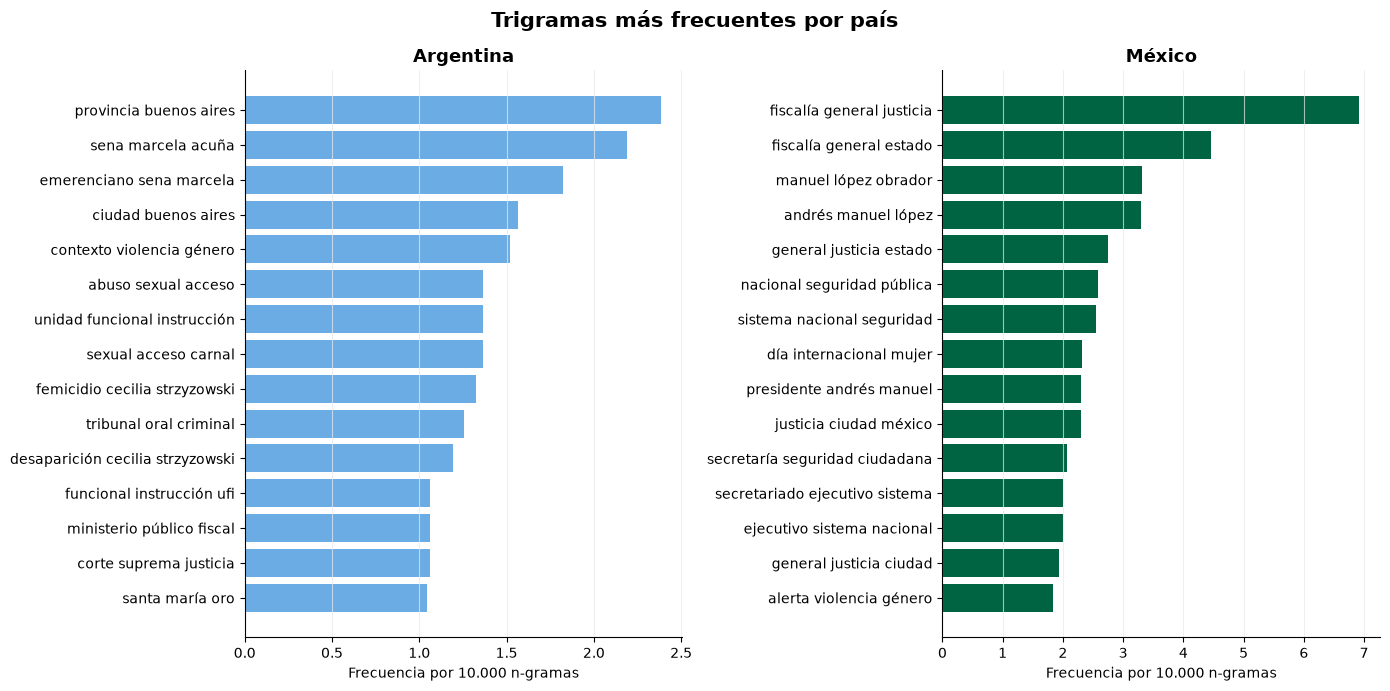

In [37]:
plot_ngrams_by_country(
    bigrams,
    "Bigramas más frecuentes por país",
)

plot_ngrams_by_country(
    trigrams,
    "Trigramas más frecuentes por país",
)

### 7.6 Evolución anual de trigramas seleccionados

In [38]:
SELECTED_TRIGRAMS = [
    "contra las mujeres",
    "violencia contra las",
    "con perspectiva género",
    "contexto violencia género",
    "homicidio agravado por",
    "agravado por vínculo",
    "por delito feminicidio",
    "vista última vez",
    "general justicia estado"
]

In [39]:
annual_trigrams = build_annual_ngram_frequencies(
    analysis_corpus,
    n=3,
    selected_ngrams=SELECTED_TRIGRAMS,
)

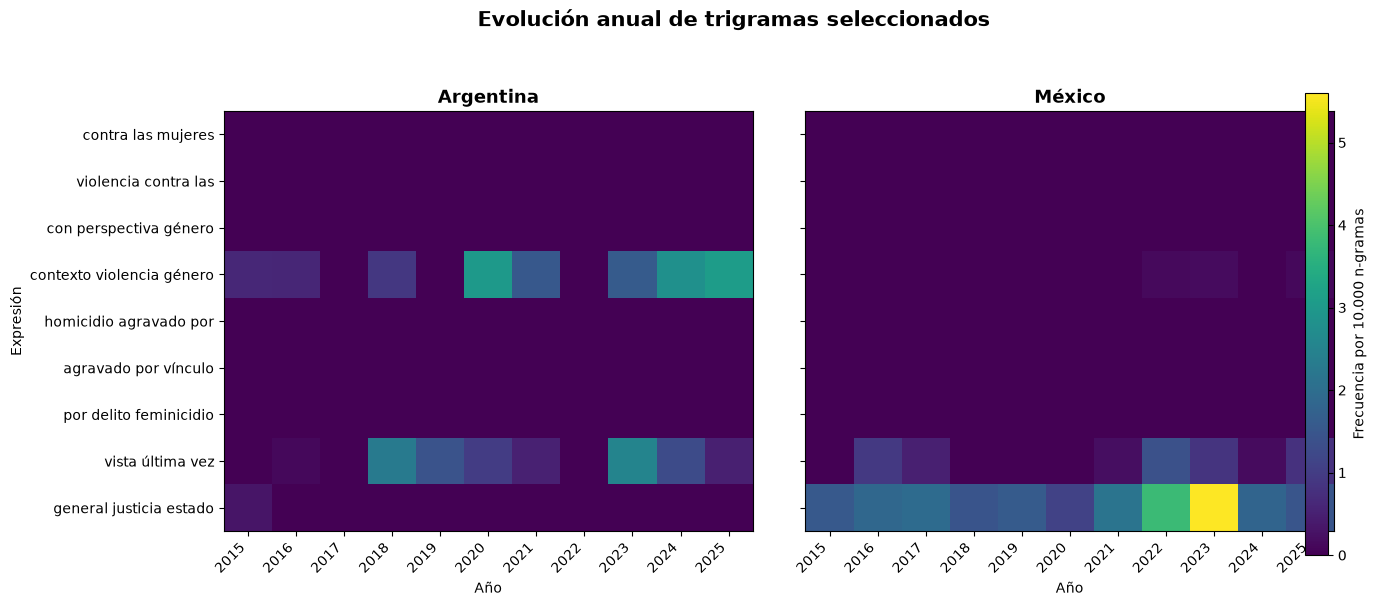

In [40]:
plot_annual_ngram_heatmaps(
    annual_trigrams,
    SELECTED_TRIGRAMS,
    "Evolución anual de trigramas seleccionados",
)

## 8. Léxico distintivo entre Argentina y México

Para evitar que los corpus de diferente tamaño dominen la comparación se utiliza un
**log-odds suavizado** sobre frecuencias documentales. Los valores positivos indican términos
relativamente más característicos del primer grupo y los negativos del segundo.

La medida identifica **especificidad dentro de este corpus**, no palabras exclusivas de un país.
Se exige además una frecuencia documental mínima conjunta para evitar términos extremadamente
raros.

In [41]:
def document_frequency(token_series):
    """
    Calcula la frecuencia documental de cada término.

    Para cada documento, un término se cuenta como máximo una vez.
    """
    counter = Counter()

    for tokens in token_series.dropna():
        counter.update(set(tokens))

    return counter

In [42]:
def log_odds_document_frequency(
    df,
    group_col,
    group_a,
    group_b,
    token_col="tokens",
    min_df=15,
    alpha=0.5,
):
    a = df.loc[df[group_col].eq(group_a), token_col]
    b = df.loc[df[group_col].eq(group_b), token_col]

    ca = document_frequency(a)
    cb = document_frequency(b)

    na = len(a)
    nb = len(b)

    vocabulary = sorted(set(ca) | set(cb))
    rows = []

    for term in vocabulary:
        a_term = ca.get(term, 0)
        b_term = cb.get(term, 0)

        if a_term + b_term < min_df:
            continue

        # Log-odds de presencia documental con suavizado.
        odds_a = (a_term + alpha) / (na - a_term + alpha)
        odds_b = (b_term + alpha) / (nb - b_term + alpha)

        rows.append({
            "Termino": term,
            f"DF_{group_a}": a_term,
            f"DF_{group_b}": b_term,
            f"Pct_{group_a}": 100 * a_term / na if na else np.nan,
            f"Pct_{group_b}": 100 * b_term / nb if nb else np.nan,
            "Log_odds": math.log(odds_a) - math.log(odds_b),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("Log_odds", ascending=False)
        .reset_index(drop=True)
    )


country_log_odds = log_odds_document_frequency(
    analysis_corpus,
    group_col="country",
    group_a="Argentina",
    group_b="México",
    min_df=15,
)

display(country_log_odds.head(20))
display(country_log_odds.tail(20).sort_values("Log_odds"))

save_table(
    country_log_odds,
    "07_log_odds_argentina_mexico.csv",
)

,Termino,DF_Argentina,DF_México,Pct_Argentina,Pct_México,Log_odds
0,clarín,246,0,20.500,0.000,7.044
1,provincial,168,0,14.000,0.000,6.585
2,nacion,160,0,13.333,0.000,6.529
3,femicida,143,0,11.917,0.000,6.401
4,mirá,142,0,11.833,0.000,6.393
5,sena,122,0,10.167,0.000,6.223
6,strzyzowski,118,0,9.833,0.000,6.186
7,emerenciano,114,0,9.500,0.000,6.148
8,pericias,100,0,8.333,0.000,6.005
9,capitanich,86,0,7.167,0.000,5.842


,Termino,DF_Argentina,DF_México,Pct_Argentina,Pct_México,Log_odds
7503,feminicida,0,326,0.000,14.691,-6.026
7502,cuauhtémoc,0,144,0.000,6.489,-5.119
7501,reclusorio,0,124,0.000,5.588,-4.960
7499,secretariado,0,123,0.000,5.543,-4.952
7500,fge,0,123,0.000,5.543,-4.952
7498,cdmx,0,120,0.000,5.408,-4.926
7497,chihuahua,0,112,0.000,5.047,-4.853
7496,guanajuato,0,97,0.000,4.371,-4.703
7495,feminicidio,18,1400,1.500,63.091,-4.694
7494,oaxaca,0,93,0.000,4.191,-4.659


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\07_log_odds_argentina_mexico.csv


Figura: outputs\reports\figures\04_analisis_longitudinal_discursivo\04_lexico_distintivo_argentina_mexico.png


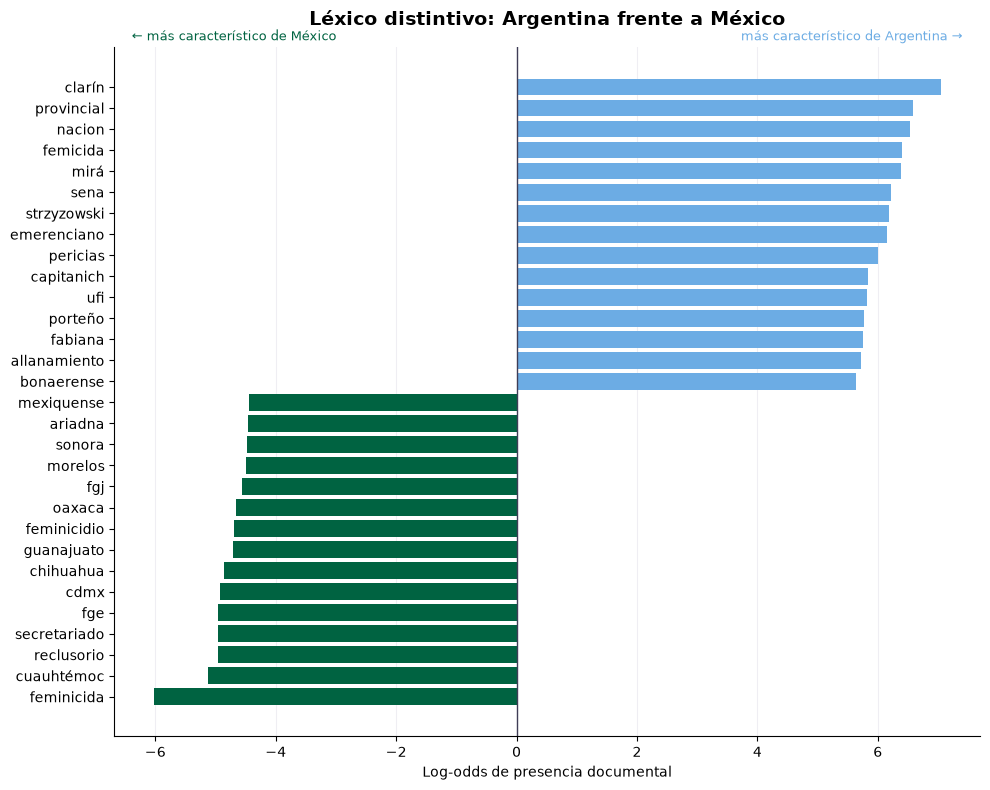

In [43]:
n_terms = 15

arg_terms = country_log_odds.nlargest(n_terms, "Log_odds")
mx_terms = country_log_odds.nsmallest(n_terms, "Log_odds")

distinctive_plot = pd.concat([mx_terms, arg_terms]).sort_values("Log_odds")

fig, ax = plt.subplots(figsize=(10, 8))

colors = [
    COUNTRY_COLORS["Argentina"] if value > 0 else COUNTRY_COLORS["México"]
    for value in distinctive_plot["Log_odds"]
]

ax.barh(
    distinctive_plot["Termino"],
    distinctive_plot["Log_odds"],
    color=colors,
)

ax.axvline(0, color=TEXT_COLOR, linewidth=1)

ax.set_title(
    "Léxico distintivo: Argentina frente a México",
    fontsize=14,
    fontweight="bold",
    pad=16
)
ax.set_xlabel("Log-odds de presencia documental")
ax.set_ylabel("")

ax.text(
    0.02,
    1.01,
    "← más característico de México",
    transform=ax.transAxes,
    ha="left",
    color=COUNTRY_COLORS["México"],
    fontsize=9,
)
ax.text(
    0.98,
    1.01,
    "más característico de Argentina →",
    transform=ax.transAxes,
    ha="right",
    color=COUNTRY_COLORS["Argentina"],
    fontsize=9,
)

clean_axes(ax, axis="x")

fig.tight_layout()
save_figure(fig, "04_lexico_distintivo_argentina_mexico.png")
plt.show()

## 9. Cambio léxico entre el periodo inicial y el reciente

Para estudiar evolución sin depender de fluctuaciones anuales pequeñas, se compara el periodo
**2015–2018** con **2022–2025** dentro de cada país. El periodo 2019–2021 queda como intervalo
intermedio y puede utilizarse para comprobar si los cambios observados son graduales.

Los resultados muestran términos relativamente más frecuentes en documentos del periodo
reciente frente al inicial; no deben interpretarse automáticamente como cambios sociales o
causales.

In [44]:
temporal_log_odds = {}

for country in ["Argentina", "México"]:
    subset = analysis_corpus.loc[
        analysis_corpus["country"].eq(country)
        & analysis_corpus["analysis_period"].isin(["2015-2018", "2022-2025"])
    ].copy()

    result = log_odds_document_frequency(
        subset,
        group_col="analysis_period",
        group_a="2022-2025",
        group_b="2015-2018",
        min_df=10,
    )

    temporal_log_odds[country] = result

    save_table(
        result,
        f"08_log_odds_temporal_{country.lower().replace('é', 'e')}.csv",
    )

    print(f"\n{country} — términos relativamente más recientes")
    display(result.head(15))

    print(f"{country} — términos relativamente más asociados al periodo inicial")
    display(result.tail(15).sort_values("Log_odds"))

Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\08_log_odds_temporal_argentina.csv

Argentina — términos relativamente más recientes


,Termino,DF_2022-2025,DF_2015-2018,Pct_2022-2025,Pct_2015-2018,Log_odds
0,nacion,160,0,30.246,0.000,6.089
1,sena,122,0,23.062,0.000,5.721
2,strzyzowski,118,0,22.306,0.000,5.678
3,emerenciano,114,0,21.550,0.000,5.634
4,capitanich,86,0,16.257,0.000,5.288
5,piqueteros,53,0,10.019,0.000,4.736
6,piquetero,47,0,8.885,0.000,4.604
7,melgarejo,45,0,8.507,0.000,4.557
8,chaqueño,43,0,8.129,0.000,4.508
9,acuña,108,1,20.416,0.197,4.465


Argentina — términos relativamente más asociados al periodo inicial


,Termino,DF_2022-2025,DF_2015-2018,Pct_2022-2025,Pct_2015-2018,Log_odds
5133,leídas,0,63,0.000,12.426,-5.019
5132,relacionadas,2,154,0.378,30.375,-4.524
5131,tambiénel,0,26,0.000,5.128,-4.065
5130,panzerini,0,21,0.000,4.142,-3.846
5129,refugios,0,18,0.000,3.550,-3.689
5128,vistos,1,49,0.189,9.665,-3.639
5127,tambiénla,0,17,0.000,3.353,-3.632
5126,huérfanos,0,15,0.000,2.959,-3.506
5125,alvarez,0,14,0.000,2.761,-3.438
5124,manifiesto,0,12,0.000,2.367,-3.285


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\08_log_odds_temporal_mexico.csv

México — términos relativamente más recientes


,Termino,DF_2022-2025,DF_2015-2018,Pct_2022-2025,Pct_2015-2018,Log_odds
0,alcaldía,128,0,9.262,0.000,4.015
1,debanhi,98,0,7.091,0.000,3.725
2,escobar,91,0,6.585,0.000,3.646
3,sheinbaum,90,0,6.512,0.000,3.634
4,carmona,78,0,5.644,0.000,3.483
5,uriel,77,0,5.572,0.000,3.469
6,mario,61,0,4.414,0.000,3.226
7,pandemia,60,0,4.342,0.000,3.209
8,márquez,59,0,4.269,0.000,3.191
9,fgj,57,0,4.124,0.000,3.156


México — términos relativamente más asociados al periodo inicial


,Termino,DF_2022-2025,DF_2015-2018,Pct_2022-2025,Pct_2015-2018,Log_odds
5415,recomendamos,1,105,0.072,38.889,-6.375
5414,nerc,0,19,0.000,7.037,-5.368
5413,cabify,0,18,0.000,6.667,-5.311
5412,jbh,0,17,0.000,6.296,-5.252
5411,mile,0,13,0.000,4.815,-4.976
5410,negrete,0,11,0.000,4.074,-4.808
5409,pgjdf,0,11,0.000,4.074,-4.808
5408,narvarte,1,20,0.072,7.407,-4.322
5407,pgj,1,14,0.072,5.185,-3.952
5406,saviñón,1,12,0.072,4.444,-3.796


Figura: outputs\reports\figures\04_analisis_longitudinal_discursivo\05_cambio_lexico_periodos.png


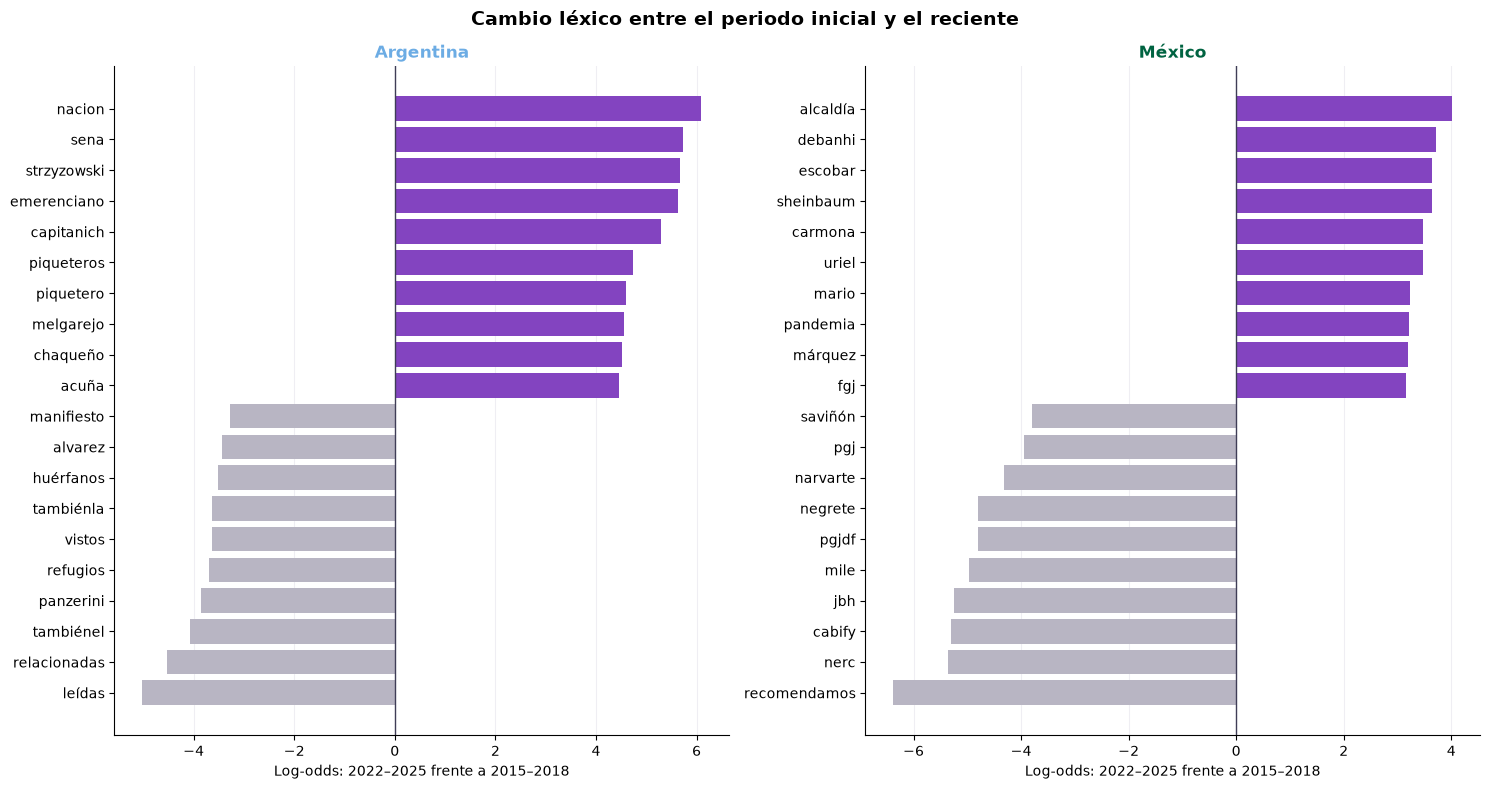

In [45]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 8),
)

for ax, country in zip(axes, ["Argentina", "México"]):
    result = temporal_log_odds[country]

    recent = result.nlargest(10, "Log_odds")
    early = result.nsmallest(10, "Log_odds")

    plot_data = (
        pd.concat([early, recent])
        .drop_duplicates("Termino")
        .sort_values("Log_odds")
    )

    colors = [
        COLORS["violet_500"] if value > 0 else COLORS["neutral"]
        for value in plot_data["Log_odds"]
    ]

    ax.barh(
        plot_data["Termino"],
        plot_data["Log_odds"],
        color=colors,
    )

    ax.axvline(0, color=TEXT_COLOR, linewidth=1)
    ax.set_title(
        country,
        fontweight="bold",
        color=COUNTRY_COLORS[country],
    )
    ax.set_xlabel("Log-odds: 2022–2025 frente a 2015–2018")
    clean_axes(ax, axis="x")

fig.suptitle(
    "Cambio léxico entre el periodo inicial y el reciente",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout()
save_figure(fig, "05_cambio_lexico_periodos.png")
plt.show()

## 10. Patrones compartidos y particulares

Para complementar el log-odds, se identifican términos extendidos en ambos países y términos
con mayor frecuencia documental en uno de ellos. Esta tabla ayuda a separar el **núcleo léxico
compartido** de las particularidades relativas.

In [46]:
country_df = {}

for country in ["Argentina", "México"]:
    subset = analysis_corpus.loc[analysis_corpus["country"].eq(country)]
    counts = document_frequency(subset["tokens"])
    n_docs = len(subset)

    country_df[country] = {
        term: 100 * count / n_docs
        for term, count in counts.items()
    }

vocab = sorted(set(country_df["Argentina"]) | set(country_df["México"]))

shared_particular = pd.DataFrame({
    "Termino": vocab,
    "Pct_docs_Argentina": [
        country_df["Argentina"].get(term, 0)
        for term in vocab
    ],
    "Pct_docs_Mexico": [
        country_df["México"].get(term, 0)
        for term in vocab
    ],
})

shared_particular["Min_pct_ambos"] = shared_particular[
    ["Pct_docs_Argentina", "Pct_docs_Mexico"]
].min(axis=1)

shared_particular["Diferencia_pp_ARG_MX"] = (
    shared_particular["Pct_docs_Argentina"]
    - shared_particular["Pct_docs_Mexico"]
)

shared_terms = (
    shared_particular
    .sort_values("Min_pct_ambos", ascending=False)
    .head(30)
)

display(shared_terms)

save_table(
    shared_particular.sort_values("Min_pct_ambos", ascending=False),
    "09_patrones_compartidos_paises.csv",
)

,Termino,Pct_docs_Argentina,Pct_docs_Mexico,Min_pct_ambos,Diferencia_pp_ARG_MX
6267,años,78.333,57.008,57.008,21.326
56528,violencia,55.917,51.104,51.104,4.813
31929,justicia,50.250,49.347,49.347,0.903
44994,quien,54.750,43.082,43.082,11.668
37180,mujer,61.333,41.325,41.325,20.008
56286,vida,36.833,37.179,36.833,-0.346
9286,caso,50.083,36.458,36.458,13.625
37181,mujeres,35.333,54.664,35.333,-19.331
40416,pasado,37.333,34.610,34.610,2.723
10662,ciudad,34.583,40.469,34.583,-5.885


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\09_patrones_compartidos_paises.csv


## 11. Heterogeneidad entre medios

Antes de atribuir una diferencia al país se examina la variación entre periódicos. Primero se
calcula la distribución de modalidades de reconocimiento dentro de cada medio y luego la
concentración de fuentes por país-año.

In [47]:
recognition_source = (
    analysis_corpus
    .groupby(
        ["country", "newspaper", "recognition_label"],
        observed=True,
        as_index=False,
    )
    .size()
    .rename(columns={"size": "Documentos"})
)

recognition_source["Total_medio"] = (
    recognition_source
    .groupby(["country", "newspaper"])["Documentos"]
    .transform("sum")
)

recognition_source["Porcentaje"] = (
    100
    * recognition_source["Documentos"]
    / recognition_source["Total_medio"]
)

display(recognition_source)
save_table(
    recognition_source,
    "10_modalidad_reconocimiento_por_medio.csv",
)

,country,newspaper,recognition_label,Documentos,Total_medio,Porcentaje
0,Argentina,Clarín,Femicidio/feminicidio explícito,491,667,73.613
1,Argentina,Clarín,Marco de género,50,667,7.496
2,Argentina,Clarín,Reconocimiento contextual,126,667,18.891
3,Argentina,La Nación,Femicidio/feminicidio explícito,261,363,71.901
4,Argentina,La Nación,Marco de género,34,363,9.366
5,Argentina,La Nación,Reconocimiento contextual,68,363,18.733
6,Argentina,Página/12,Femicidio/feminicidio explícito,143,170,84.118
7,Argentina,Página/12,Marco de género,12,170,7.059
8,Argentina,Página/12,Reconocimiento contextual,15,170,8.824
9,México,El Universal,Femicidio/feminicidio explícito,4,4,100.000


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\10_modalidad_reconocimiento_por_medio.csv


Figura: outputs\reports\figures\04_analisis_longitudinal_discursivo\06_modalidad_reconocimiento_por_medio.png


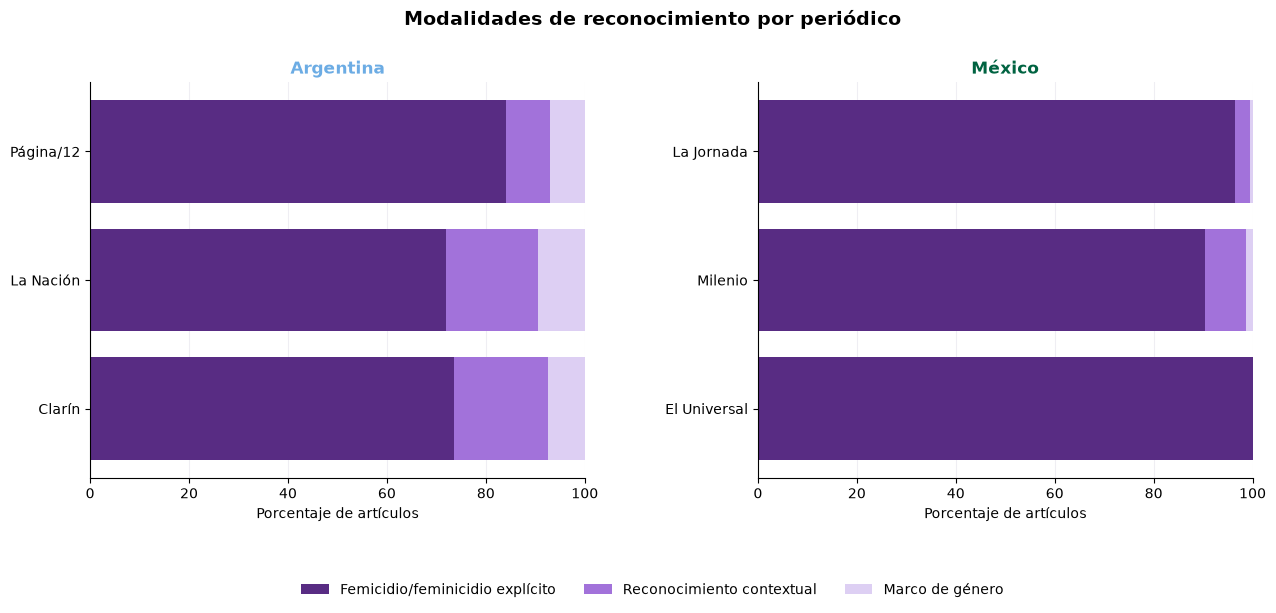

In [48]:
source_matrix = (
    recognition_source
    .pivot_table(
        index=["country", "newspaper"],
        columns="recognition_label",
        values="Porcentaje",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(columns=RECOGNITION_ORDER, fill_value=0)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    sharex=True,
)

for ax, country in zip(axes, ["Argentina", "México"]):
    if country not in source_matrix.index.get_level_values("country"):
        continue

    subset = source_matrix.loc[country].copy()

    order = [
        source
        for source in SOURCE_ORDER[country]
        if source in subset.index
    ]
    subset = subset.reindex(order)

    y = np.arange(len(subset))
    left = np.zeros(len(subset))

    for category in RECOGNITION_ORDER:
        values = subset[category].to_numpy()

        ax.barh(
            y,
            values,
            left=left,
            color=RECOGNITION_COLORS[category],
            label=category,
        )
        left += values

    ax.set_yticks(y)
    ax.set_yticklabels(subset.index)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Porcentaje de artículos")
    ax.set_title(
        country,
        fontweight="bold",
        color=COUNTRY_COLORS[country],
    )
    clean_axes(ax, axis="x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Modalidades de reconocimiento por periódico",
    fontsize=14,
    fontweight="bold",
)

fig.subplots_adjust(bottom=0.20, top=0.86, wspace=0.35)
save_figure(fig, "06_modalidad_reconocimiento_por_medio.png")
plt.show()

### 11.1 Concentración de fuentes por país y año

Se calcula el índice Herfindahl–Hirschman (HHI) sobre la participación documental de los medios
en cada país-año:

\[
HHI=\sum_i s_i^2
\]

donde \(s_i\) es la proporción de artículos aportada por el medio \(i\). Con tres medios, valores
más altos indican mayor concentración de la muestra en uno o pocos periódicos. Este control es
importante para interpretar cambios temporales.

In [49]:
source_year = (
    analysis_corpus
    .groupby(
        ["country", "analysis_year", "newspaper"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "Documentos"})
)

source_year["Total_pais_anio"] = (
    source_year
    .groupby(["country", "analysis_year"])["Documentos"]
    .transform("sum")
)

source_year["Share"] = (
    source_year["Documentos"]
    / source_year["Total_pais_anio"]
)

source_concentration = (
    source_year
    .assign(Share2=lambda df: df["Share"] ** 2)
    .groupby(["country", "analysis_year"], as_index=False)
    .agg(
        HHI=("Share2", "sum"),
        Medios_representados=("newspaper", "nunique"),
        Documentos=("Documentos", "sum"),
    )
)

display(source_concentration)
save_table(
    source_concentration,
    "11_concentracion_fuentes_pais_anio.csv",
)

,country,analysis_year,HHI,Medios_representados,Documentos
0,Argentina,2015,0.516,2,112
1,Argentina,2016,0.500,2,229
2,Argentina,2017,1.000,1,100
3,Argentina,2018,0.970,2,66
4,Argentina,2019,1.000,1,63
5,Argentina,2020,1.000,1,51
6,Argentina,2021,1.000,1,50
7,Argentina,2022,0.825,2,31
8,Argentina,2023,0.550,2,216
9,Argentina,2024,0.699,2,103


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\11_concentracion_fuentes_pais_anio.csv


Figura: outputs\reports\figures\04_analisis_longitudinal_discursivo\07_concentracion_fuentes_pais_anio.png


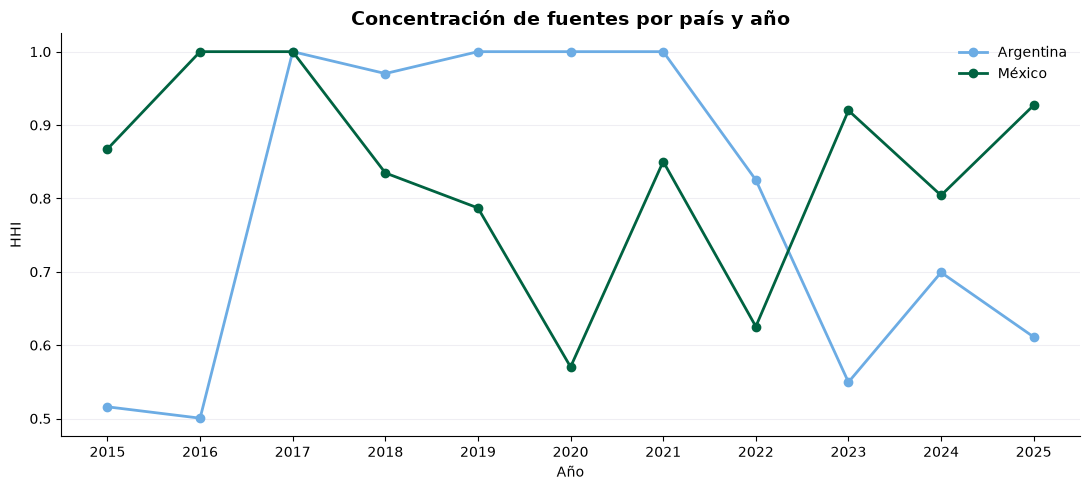

In [50]:
fig, ax = plt.subplots(figsize=(11, 5))

for country in ["Argentina", "México"]:
    subset = (
        source_concentration
        .loc[source_concentration["country"].eq(country)]
        .sort_values("analysis_year")
    )

    ax.plot(
        subset["analysis_year"],
        subset["HHI"],
        marker="o",
        linewidth=2,
        label=country,
        color=COUNTRY_COLORS[country],
    )

ax.set_title(
    "Concentración de fuentes por país y año",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Año")
ax.set_ylabel("HHI")
ax.set_xticks(range(START_YEAR, END_YEAR + 1))
ax.legend(frameon=False)
clean_axes(ax)

fig.tight_layout()
save_figure(fig, "07_concentracion_fuentes_pais_anio.png")
plt.show()

## 12. Análisis de sensibilidad por composición mediática

Como control, se calcula para cada país-año la participación del medio dominante. Los años con
alta concentración deben interpretarse con especial cautela en las comparaciones longitudinales:
un cambio aparente puede reflejar parcialmente un cambio en qué periódico aporta más documentos.

In [51]:
dominant_source = (
    source_year
    .sort_values(
        ["country", "analysis_year", "Share"],
        ascending=[True, True, False],
    )
    .groupby(["country", "analysis_year"], as_index=False)
    .first()
    .rename(columns={
        "newspaper": "Medio_dominante",
        "Share": "Participacion_medio_dominante",
    })
)

dominant_source["Participacion_medio_dominante_pct"] = (
    100 * dominant_source["Participacion_medio_dominante"]
)

sensitivity_source = dominant_source.merge(
    source_concentration[
        ["country", "analysis_year", "HHI", "Medios_representados"]
    ],
    on=["country", "analysis_year"],
    how="left",
)

display(sensitivity_source)

save_table(
    sensitivity_source,
    "12_sensibilidad_composicion_mediatica.csv",
)

,country,analysis_year,Medio_dominante,Documentos,Total_pais_anio,Participacion_medio_dominante,Participacion_medio_dominante_pct,HHI,Medios_representados
0,Argentina,2015,Clarín,66,112,0.589,58.929,0.516,2
1,Argentina,2016,Página/12,118,229,0.515,51.528,0.500,2
2,Argentina,2017,Clarín,100,100,1.000,100.000,1.000,1
3,Argentina,2018,Clarín,65,66,0.985,98.485,0.970,2
4,Argentina,2019,Clarín,63,63,1.000,100.000,1.000,1
5,Argentina,2020,Clarín,51,51,1.000,100.000,1.000,1
6,Argentina,2021,Clarín,50,50,1.000,100.000,1.000,1
7,Argentina,2022,Clarín,28,31,0.903,90.323,0.825,2
8,Argentina,2023,La Nación,142,216,0.657,65.741,0.550,2
9,Argentina,2024,La Nación,84,103,0.816,81.553,0.699,2


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\12_sensibilidad_composicion_mediatica.csv


## 13. Matriz de resultados para responder los objetivos

La siguiente tabla no sustituye la interpretación cualitativa de los resultados. Funciona como
mapa de trazabilidad entre los objetivos del TFM y las salidas producidas por este notebook.

In [52]:
objective_map = pd.DataFrame({
    "Objetivo": [
        "1. Patrones léxicos y discursivos",
        "1. Patrones léxicos y discursivos",
        "1. Patrones léxicos y discursivos",
        "2. Reconocimiento y denominación",
        "2. Reconocimiento y denominación",
        "3. Patrones compartidos y particularidades",
        "3. Patrones compartidos y particularidades",
        "Control de interpretación",
    ],
    "Análisis": [
        "Frecuencia documental de términos",
        "Bigramas",
        "Cambio léxico 2015-2018 vs. 2022-2025",
        "Modalidades de reconocimiento por país-año",
        "Expresiones de denominación por 10.000 palabras",
        "Log-odds Argentina vs. México",
        "Núcleo léxico compartido",
        "Concentración y composición por medio",
    ],
    "Salida principal": [
        "05_terminos_frecuencia_documental.csv",
        "06_bigramas_frecuencia_documental.csv",
        "08_log_odds_temporal_*.csv",
        "01_modalidad_reconocimiento_pais_anio.csv",
        "03_denominaciones_pais_anio.csv",
        "07_log_odds_argentina_mexico.csv",
        "09_patrones_compartidos_paises.csv",
        "11_concentracion_fuentes_pais_anio.csv",
    ],
})

display(objective_map)
save_table(
    objective_map,
    "13_mapa_objetivos_resultados.csv",
)

,Objetivo,Análisis,Salida principal
0,1. Patrones léxicos y discursivos,Frecuencia documental de términos,05_terminos_frecuencia_documental.csv
1,1. Patrones léxicos y discursivos,Bigramas,06_bigramas_frecuencia_documental.csv
2,1. Patrones léxicos y discursivos,Cambio léxico 2015-2018 vs. 2022-2025,08_log_odds_temporal_*.csv
3,2. Reconocimiento y denominación,Modalidades de reconocimiento por país-año,01_modalidad_reconocimiento_pais_anio.csv
4,2. Reconocimiento y denominación,Expresiones de denominación por 10.000 palabras,03_denominaciones_pais_anio.csv
5,3. Patrones compartidos y particularidades,Log-odds Argentina vs. México,07_log_odds_argentina_mexico.csv
6,3. Patrones compartidos y particularidades,Núcleo léxico compartido,09_patrones_compartidos_paises.csv
7,Control de interpretación,Concentración y composición por medio,11_concentracion_fuentes_pais_anio.csv


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\13_mapa_objetivos_resultados.csv


## 14. Resumen cuantitativo para la redacción de resultados

Esta celda genera un conjunto compacto de indicadores verificables. La interpretación narrativa
debe redactarse después de inspeccionar las tablas y figuras completas, evitando seleccionar
únicamente años o términos llamativos.

In [53]:
# Vocabulario observado
unigram_vocabulary = set()

# N-gramas observados
bigram_vocabulary = set()
trigram_vocabulary = set()

for tokens in analysis_corpus["tokens"]:

    if not isinstance(tokens, list):
        continue

    unigram_vocabulary.update(tokens)

    bigram_vocabulary.update(
        tuple(tokens[i:i+2])
        for i in range(len(tokens) - 1)
    )

    trigram_vocabulary.update(
        tuple(tokens[i:i+3])
        for i in range(len(tokens) - 2)
    )


summary = pd.DataFrame({
    "Indicador": [
        "Documentos elegibles",
        "Países",
        "Medios",
        "Años analizados",
        "Periodo analizado",
        "Tokens analizados tras normalización",
        "Unigramas distintos observados",
        "Términos incluidos en comparación log-odds",
        "Bigramas distintos observados",
        "Trigramas distintos observados",
        "Unigramas seleccionados para evolución temporal",
        "Bigramas seleccionados para evolución temporal",
        "Trigramas seleccionados para evolución temporal",
    ],

    "Valor": [
        len(analysis_corpus),
        analysis_corpus["country"].nunique(),
        analysis_corpus["newspaper"].nunique(),
        analysis_corpus["analysis_year"].nunique(),

        (
            f"{int(analysis_corpus['analysis_year'].min())}"
            f"–{int(analysis_corpus['analysis_year'].max())}"
        ),

        int(
            analysis_corpus["token_count_nlp"].sum()
        ),

        len(unigram_vocabulary),

        len(country_log_odds),

        len(bigram_vocabulary),

        len(trigram_vocabulary),

        len(HEATMAP_TERMS),

        len(SELECTED_BIGRAMS),

        len(SELECTED_TRIGRAMS),
    ],
})

display(summary)

save_table(
    summary,
    "14_resumen_analisis.csv",
)

,Indicador,Valor
0,Documentos elegibles,3419
1,Países,2
2,Medios,6
3,Años analizados,11
4,Periodo analizado,2015–2025
5,Tokens analizados tras normalización,1008257
6,Unigramas distintos observados,57965
7,Términos incluidos en comparación log-odds,7504
8,Bigramas distintos observados,675640
9,Trigramas distintos observados,894232


Tabla: outputs\reports\tables\04_analisis_longitudinal_discursivo\14_resumen_analisis.csv


## 15. Criterios para interpretar los resultados

Al redactar el capítulo de resultados deben mantenerse separados tres niveles:

1. **Cobertura:** cuántos documentos y medios están disponibles en cada país-año.
2. **Descripción:** qué proporciones, expresiones y patrones léxicos se observan.
3. **Interpretación:** qué significado puede tener el cambio observado a la luz del contexto
   histórico, normativo o mediático.

Una variación temporal no debe atribuirse automáticamente a un acontecimiento externo. Antes
de hacerlo deben comprobarse la cobertura del año, la composición por medio, la persistencia del
patrón en periodos adyacentes y, cuando corresponda, evidencia documental externa.

Las tablas generadas por este notebook quedan disponibles en
`outputs/reports/tables/04_analisis_longitudinal_discursivo/` y las figuras en
`outputs/reports/figures/04_analisis_longitudinal_discursivo/`.